In [23]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cns.data_utils import load_data, img_path, filter_samples, load_merged_samples, load_samples_out
file_type = ".png"

In [25]:
data = load_data()
datasets = list(data.keys())

In [26]:
cutoff = np.arange(0, 1, 0.0005)
sample_count = {}
for k, v in data.items():
    sample_count[k] = []
    for i in cutoff:
        below = v.samples.query(f"ane_total_cn_frac_aut <= {i}").shape[0]
        sample_count[k].append(below / v.samples.shape[0])

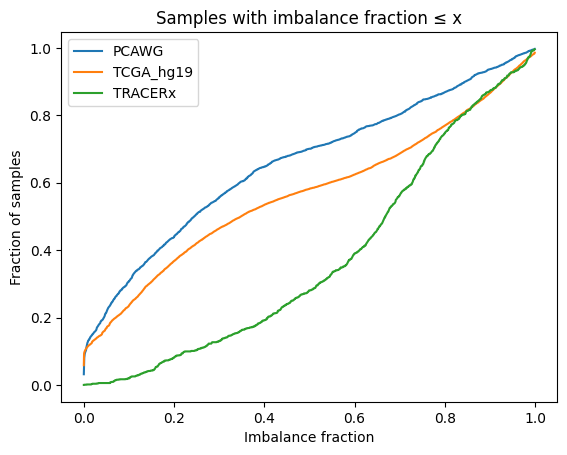

In [27]:
for k, v in sample_count.items():
    plt.plot(cutoff, v, label=k)
plt.xlabel("Imbalance fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with imbalance fraction ≤ x")

plt.savefig(f"{img_path}/fig_samples_imbalance_fraction_full{file_type}")

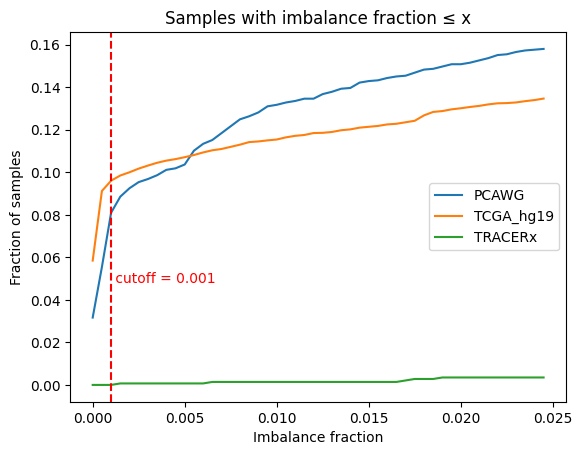

In [28]:
for k, v in sample_count.items():
    plt.plot(cutoff[:50], v[:50], label=k)
# add a vertical line at 0.01
plt.axvline(x=0.001, color="red", linestyle="--")
plt.xlabel("Imbalance fraction")
plt.ylabel("Fraction of samples")
plt.title(f"Samples with imbalance fraction ≤ x")
plt.legend()
# add a text to the vertical line
plt.text(0.001, 0.05, " cutoff = 0.001", rotation=0, verticalalignment="center", horizontalalignment="left", color="red")


plt.savefig(f"{img_path}/fig_samples_imbalance_fraction{file_type}")

In [29]:
cutoff = np.arange(0, 1.001, 0.001)
coverage_count = {}
for k, v in data.items():
    coverage_count[k] = []
    for i in cutoff:
        below = v.samples.query(f"cover_frac_aut <= {i}").shape[0]
        coverage_count[k].append(below / v.samples.shape[0])

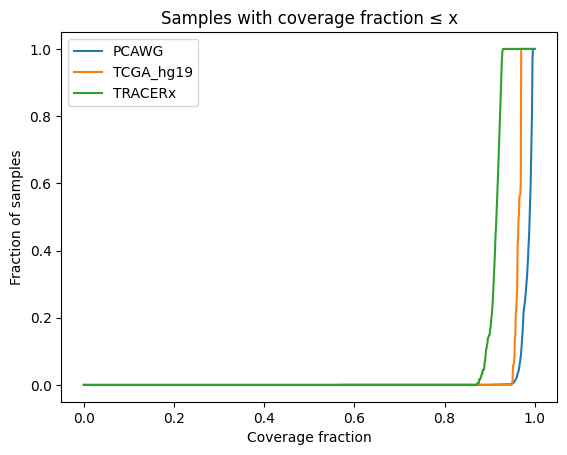

In [30]:
for k, v in coverage_count.items():
    plt.plot(cutoff, v, label=k)

plt.xlabel("Coverage fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title("Samples with coverage fraction ≤ x")


plt.savefig(f"{img_path}/fig_samples_coverage_fraction_full{file_type}")

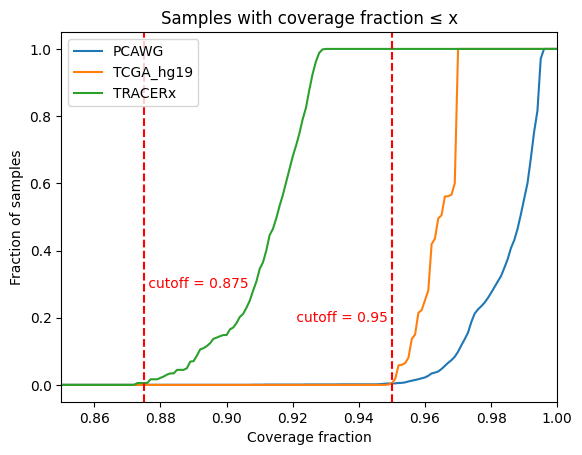

In [31]:
for k, v in coverage_count.items():
    plt.plot(cutoff, v, label=k)
plt.xlim(0.85, 1)

# add vertical line at .95
plt.axvline(x=0.95, color="red", linestyle="--")
plt.xlabel("Coverage fraction")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title("Samples with coverage fraction ≤ x")

# add a text to the vertical line
plt.text(0.95, 0.2, " cutoff = 0.95 ", rotation=0, verticalalignment="center", horizontalalignment="right", color="red")

plt.axvline(x=0.875, color="red", linestyle="--")
plt.text(0.875, 0.3, " cutoff = 0.875 ", rotation=0, verticalalignment="center", horizontalalignment="left", color="red")

plt.savefig(f"{img_path}/fig_samples_coverage_fraction{file_type}")

In [32]:
samples = {
	"PCAWG": load_samples_out("PCAWG_samples.tsv"),
	"TRACERx": load_samples_out("TRACERx_samples.tsv"),
	"TCGA": load_samples_out("TCGA_hg19_samples.tsv")
}
filtered_samples = {}
overlap_with_tcga = samples["PCAWG"].index[samples["PCAWG"]["TCGA_id"].notna()]
print(f"Overlapping samples with TCGA: {len(overlap_with_tcga)}")
for k, v in samples.items():
	min_frac = 0.95 if k != "TRACERx" else 0.875
	print(k)
	print(f"Original size: {len(v)} samples")
	filtered_samples[k] = filter_samples(v, cover_min_frac=min_frac, whitelist=k=="PCAWG", remove_uncertain=k=="TRACERx", print_info=True)


Overlapping samples with TCGA: 828
PCAWG
Original size: 2778 samples
Total samples: 2778
225 samples are CN neutral
12 samples have low coverage
195 samples are blacklisted
Filtered samples: 2374
TRACERx
Original size: 1428 samples
Total samples: 1428
0 samples are CN neutral
8 samples have low coverage
248 samples do not have exact type
Filtered samples: 1172
TCGA
Original size: 9868 samples
Total samples: 9868
948 samples are CN neutral
46 samples have low coverage
Filtered samples: 8874


In [33]:
merged_samples = load_merged_samples(True)

PCAWG
Total samples: 2778
225 samples are CN neutral
12 samples have low coverage
195 samples are blacklisted
Filtered samples: 2374
TRACERx
Total samples: 1428
0 samples are CN neutral
8 samples have low coverage
248 samples do not have exact type
Filtered samples: 1172
TCGA_hg19
Total samples: 9868
948 samples are CN neutral
46 samples have low coverage
Filtered samples: 8874
Overlapping samples with PCAWG: 748
After overlap removal: 8261
Total samples: 11807


In [34]:
ane_min_frac = 0.001

# Filter samples for each condition
condition1 = samples["TCGA"][samples["TCGA"]["breaks_aut"] < 4]
condition2 = samples["TCGA"].query(f"ane_major_cn_frac_aut < {ane_min_frac} & ane_major_cn_frac_aut < {ane_min_frac}")

# Find samples that meet both conditions
both_conditions = samples["TCGA"][(samples["TCGA"]["breaks_aut"] < 4) & (samples["TCGA"]["ane_major_cn_frac_aut"] < ane_min_frac) & (samples["TCGA"]["ane_major_cn_frac_aut"] < ane_min_frac)]

# Count samples for each condition
count_condition1 = len(condition1)
count_condition2 = len(condition2)
count_both_conditions = len(both_conditions)

count_condition1, count_condition2, count_both_conditions

(1176, 1127, 745)

In [35]:
cutoff = np.arange(0, 1001, 1)
break_count = {}
for k, v in data.items():
    break_count[k] = []
    for i in cutoff:
        below = v.samples.query(f"breaks_aut <= {i}").shape[0]
        break_count[k].append(below / v.samples.shape[0])

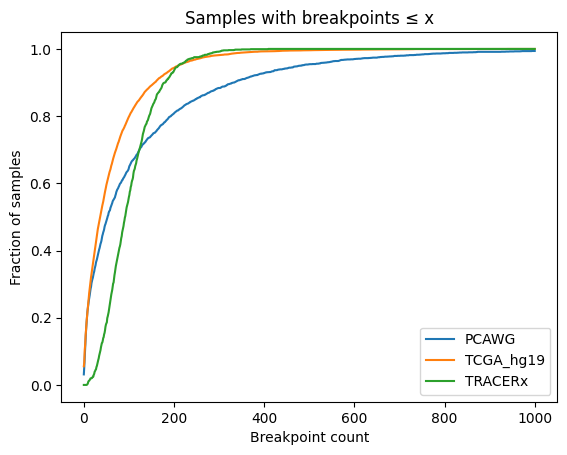

In [38]:
for k, v in break_count.items():
    plt.plot(cutoff, v, label=k)
plt.xlabel("Breakpoint count")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with breakpoints ≤ x")

plt.savefig(f"{img_path}/fig_samples_breaks_fraction_full{file_type}")

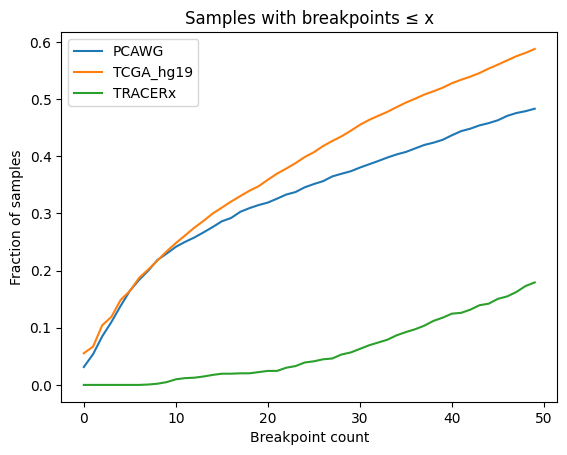

In [40]:
for k, v in break_count.items():
    plt.plot(cutoff[:50], v[:50], label=k)

plt.xlabel("Breakpoint count")
plt.ylabel("Fraction of samples")
plt.legend()
plt.title(f"Samples with breakpoints ≤ x")

plt.savefig(f"{img_path}/fig_samples_breaks_fraction{file_type}")